# Analysis


In [5]:
## Imports we'll need

import json
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default') # seaborn, ggplot
import matplotlib.cm as cm

#It tells Pandas: "Stop using 'e' notation 
# and just show me two decimal places for all floats."
pd.options.display.float_format = '{:,.2f}'.format


data_file = 'clean_data_for_analysis.csv'
df = pd.read_csv(data_file)

### Explore Data

- **Creating a regions columns:**
    Based on zipcode, needed for some analysis

- **Recount** : 26655 rows, 24 columns 

- **Visualizing health_data**
    Examined data health in total and by property type:
    - -> Created data_health, the average of missing values per columns **! High number = Healthy !**
    - -> data_health_by_type, the same grouped by type of properties **! High number = Healthy !**


- **Distributions**


- **Correlations**


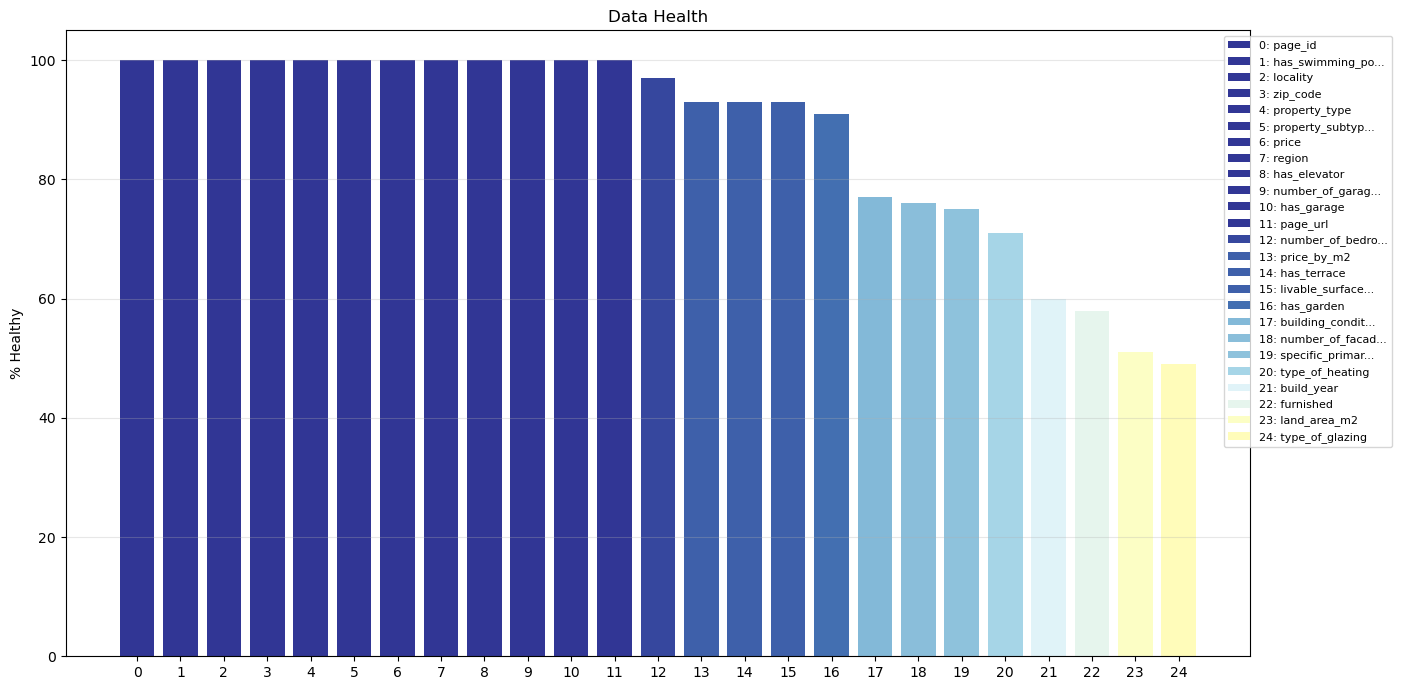

In [ ]:
## Visualizing health_data
data_health = (100-(df.isna().mean()*100)).round().sort_values(ascending=False)

## Working on colors:
cmap = plt.get_cmap('RdYlBu') # get the colormap into a variable.
norm = plt.Normalize(vmin=0, vmax=100) # normalise the values for the colormap
colors = cmap(norm(data_health.values)) # sets colors as the color map, on the normalise values, on the values

## Setting the stage of the graph.
fig, ax = plt.subplots(figsize=(14,7),)
labels = [label[:15]+"..." if len(label) > 15 else label for label in data_health.index]
labels_num = list(range(len(data_health.index)))
legends = []
for i in range(len(labels)):
    legends.append(f"{i}: {labels[i]}")

    


### Building the graph
bars = ax.bar(data_health.index, data_health.values, color=colors ) #color='coolwarm' # color="plasma"
ax.set_title("Data Health")
ax.set_ylabel("% Healthy")
ax.grid(True, alpha=0.3, axis="y")
ax.set_xticks(range(len(data_health.index)))
ax.set_xticklabels(labels_num)
ax.legend(bars, legends, loc="upper right", bbox_to_anchor=(1.125, 1), fontsize=8, frameon=True)

plt.xticks()
plt.tight_layout()
plt.show()

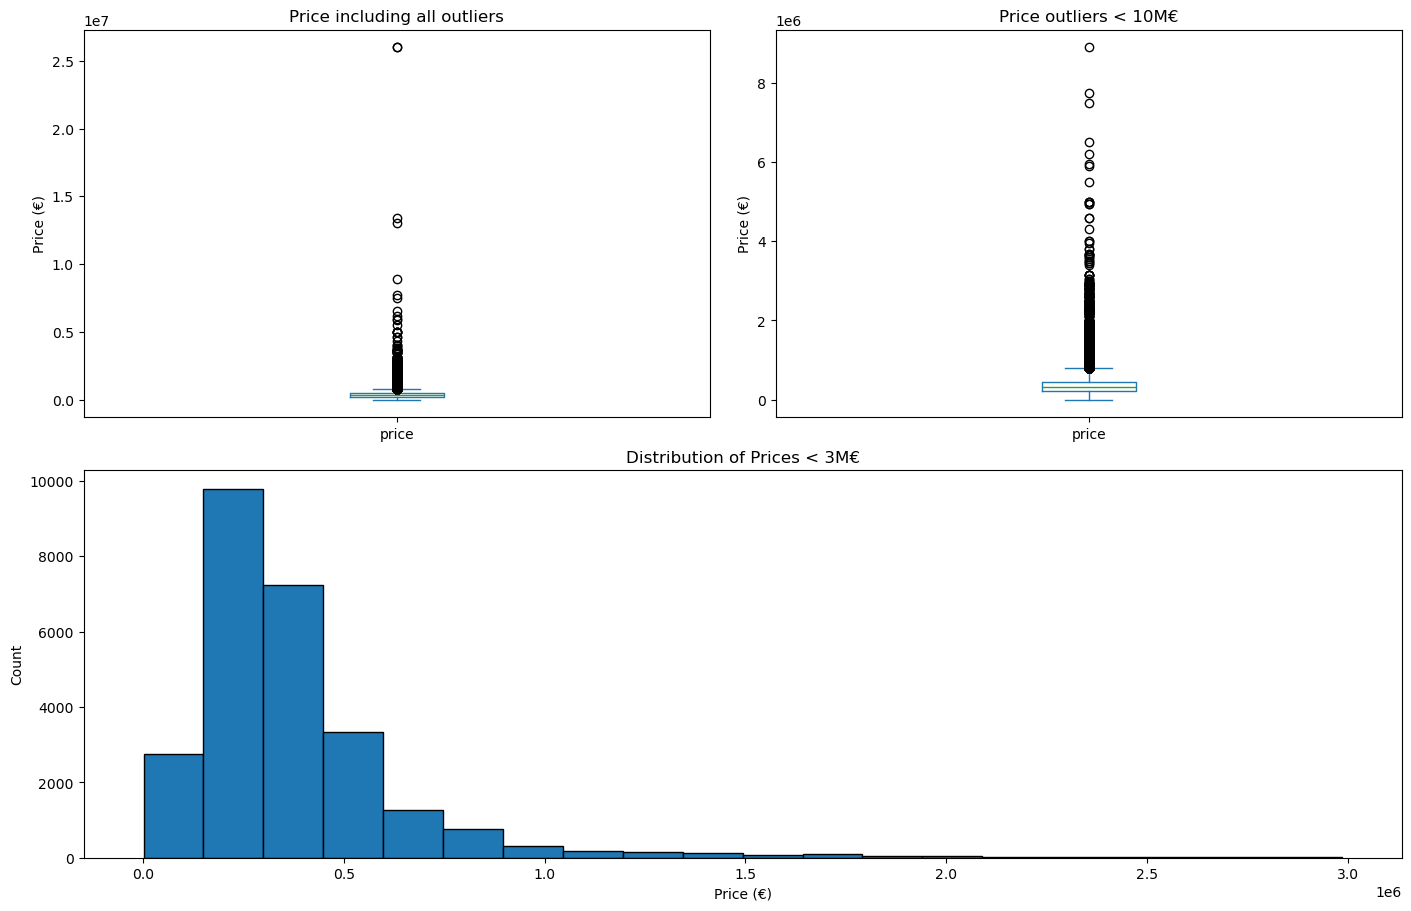

In [ ]:
## Vizualize price distributions:


fig = plt.figure(figsize=(14, 9), constrained_layout=True)
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])   # bottom row, full width

df["price"].plot.box(ax=ax1)
ax1.set_title("Price including all outliers")
ax1.set_ylabel("Price (€)")

df.loc[df["price"] <= 10_000_000, "price"].plot.box(ax=ax2)
ax2.set_title("Price outliers < 10M€")
ax2.set_ylabel("Price (€)")

df.loc[df["price"] < 3_000_000, "price"].plot.hist(ax=ax3, bins=20, edgecolor="k")
ax3.set_title("Distribution of Prices < 3M€")
ax3.set_xlabel("Price (€)")
ax3.set_ylabel("Count")

plt.show()


In [ ]:
## random

df["price"].mean().round(2)
df["price"].median()

df.groupby('region')["price"].median()
#df.groupby('region')(["price"].mean().round(2))

price_stats = df["price"].agg(["mean", "median"])
price_stats["mean"] = price_stats["mean"].round(2)

#print(price_stats)




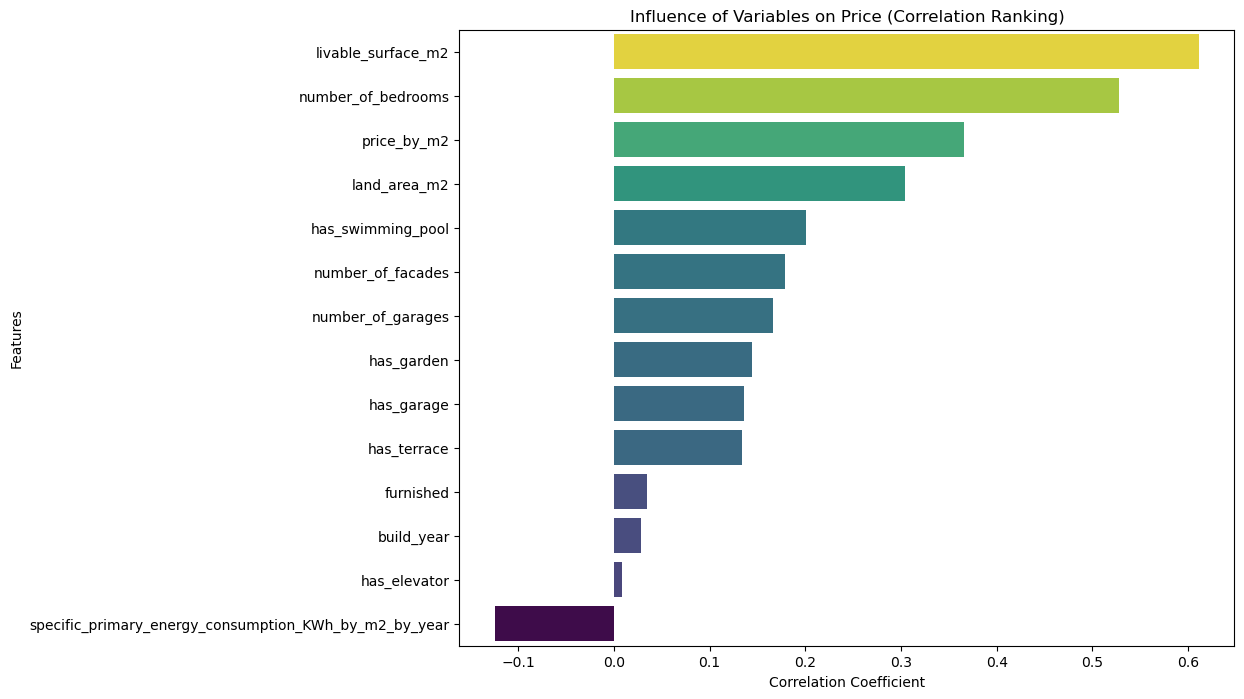

In [ ]:
# 1. Isolate the 'price_eur' column from the correlation matrix
# and sort the values so the highest is at the top
# 2. We remove 'price_eur' itself (because it's always 1.0)
price_correlations = df.corr(numeric_only=True)['price'].sort_values(ascending=False).drop('price')#.drop('zip_code')
#print(f"{price_correlations=}")

# 3. Setup the drawing
plt.figure(figsize=(10, 8))

# 4. Create the bar plot
# We use the 'index' (column names) for the Y axis 
# and the 'values' (the correlation numbers) for the X axis
sns.barplot(x=price_correlations.values, y=price_correlations.index, palette='viridis', hue=price_correlations, legend=False)

# 5. Add labels
plt.title('Influence of Variables on Price (Correlation Ranking)')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')

plt.show()




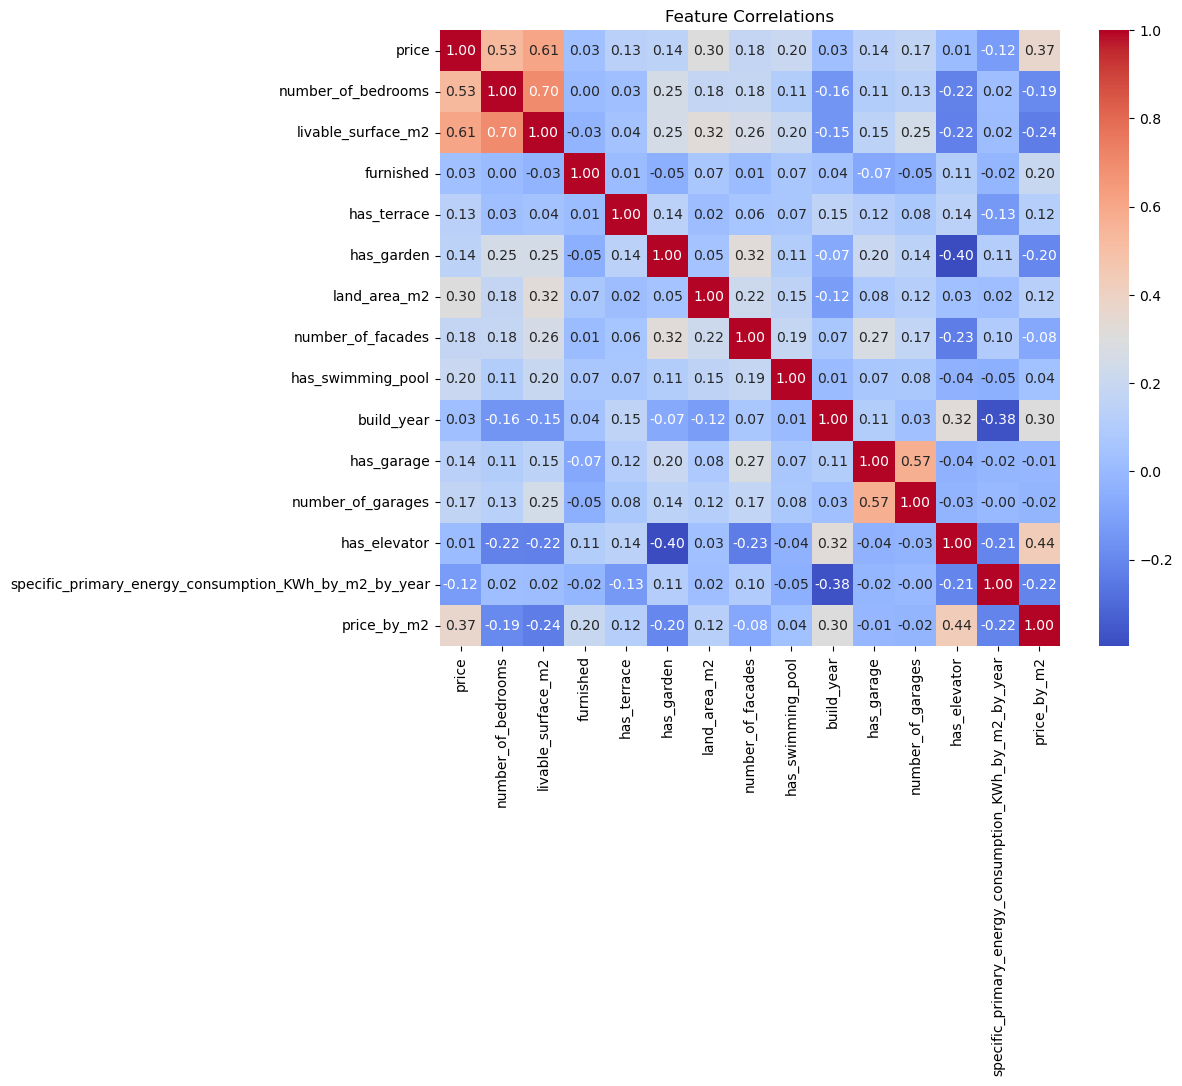

In [ ]:
## Correlations
corr_matrix = df.corr(numeric_only=True)
#print(corr_matrix.sort_values)
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Feature Correlations")
plt.show()
